In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# načtení dat
df = pd.read_csv("cities_with_all_data_druha_nemocnice.csv")

# vybereme potřebné sloupce
cols = [
    'Obec',              # nebo 'Nazev_obce', podle toho, co v CSV opravdu je
    'Total',
    'Lat_x', 'Lon_x',
    'Nejblizsi_nemocnice',
    'Vzdalenost_km',
    'Druha_nejblizsi_nemocnice',
    'Vzdalenost_druha_km'
]
df = df[cols].dropna()

# převod na čísla
df['Total'] = pd.to_numeric(df['Total'], errors='coerce')
df['Vzdalenost_km'] = pd.to_numeric(df['Vzdalenost_km'], errors='coerce')
df['Vzdalenost_druha_km'] = pd.to_numeric(df['Vzdalenost_druha_km'], errors='coerce')
df = df.dropna(subset=['Total', 'Vzdalenost_km', 'Vzdalenost_druha_km'])

# sanity check
df.head()

,Obec,Total,Lat_x,Lon_x,Nejblizsi_nemocnice,Vzdalenost_km,Druha_nejblizsi_nemocnice,Vzdalenost_druha_km
0,Želechovice nad Dřevnicí,1859.0,49.217851,17.746128,Krajská nemocnice Tomáše Bati,3.647937,EUC Klinika Zlín,6.497809
1,Petrov nad Desnou,1237.0,50.005439,17.044275,Šumperská nemocnice,7.640730,Jesenická nemocnice,27.095326
2,Libhošť,1756.0,49.627451,18.076256,Nemocnice Nový Jičín,5.977028,Nemocnice Bílovec,15.654933
3,Krhová,2161.0,49.494069,18.007677,Nemocnice Valašské Meziříčí,4.111246,Nemocnice Nový Jičín,10.667289
4,Poličná,1769.0,49.467984,17.947869,Nemocnice Valašské Meziříčí,2.182197,Nemocnice Nový Jičín,14.437018


In [3]:
results = []

for hospital in df['Nejblizsi_nemocnice'].unique():
    mask = df['Nejblizsi_nemocnice'] == hospital

    if not mask.any():
        continue

    sub = df[mask].copy()

    old_dist = sub['Vzdalenost_km'].values
    new_dist = sub['Vzdalenost_druha_km'].values
    population = sub['Total'].values

    increase = new_dist - old_dist
    increase[increase < 0] = 0  # pokud je nová vzdálenost menší, bereme nulu

    total_population = population.sum()
    total_population_increase = np.sum(population * increase)
    avg_increase_km = np.average(increase, weights=population)

    results.append({
        'hospital': hospital,
        'total_population': total_population,
        'total_population_increase': total_population_increase,
        'avg_increase_km': avg_increase_km
    })

results_df = pd.DataFrame(results).sort_values(by='total_population_increase', ascending=False)
results_df.head(10)

,hospital,total_population,total_population_increase,avg_increase_km
17,Fakultní nemocnice,325551.0,4.249853e+06,13.054339
35,Nemocnice České Budějovice,198334.0,2.995790e+06,15.104774
1,Šumperská nemocnice,161119.0,2.953971e+06,18.334092
96,Nemocnice Znojmo,105454.0,2.739005e+06,25.973458
105,Nemocnice Rychnov nad Kněžnou,193508.0,2.729967e+06,14.107775
58,Nemocnice Tábor,109085.0,2.045028e+06,18.747103
55,Klaudiánova nemocnice,128202.0,2.000509e+06,15.604354
23,Slezská nemocnice v Opavě,108623.0,1.560878e+06,14.369679
27,Nemocnice Jihlava,103789.0,1.544183e+06,14.878098
53,Nemocnice s poliklinikou Česká Lípa,101969.0,1.368032e+06,13.416154


/var/folders/w6/jccf_cg95dgctfwt3std61m00000gn/T/ipykernel_71585/150669029.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


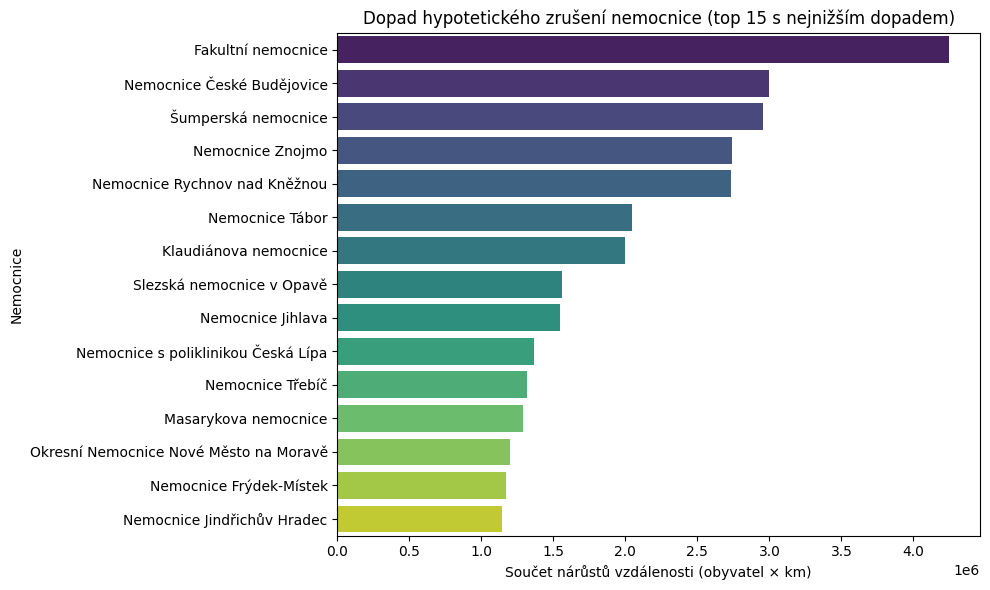

In [5]:
# seřazeno už máš; vezmeme top 15 s nejmenším dopadem
top_n = 15
plot_df = results_df.head(top_n).copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_df,
    y='hospital',
    x='total_population_increase',
    palette='viridis'
)
plt.xlabel('Součet nárůstů vzdálenosti (obyvatel × km)')
plt.ylabel('Nemocnice')
plt.title(f'Dopad hypotetického zrušení nemocnice (top {top_n} s nejnižším dopadem)')
plt.tight_layout()
plt.show()